# Nueva sección

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv(r'Amazon_Men_Wrist_Watches.csv')
df

,Unnamed: 0,brand_name,watch_name,rating,number_of_reviews,price
0,0,Casio,Vintage A-158WA-1Q Digital Grey Dial Unisex Wa...,4.4,54K,"1,894"
1,1,Casio,Youth Series Digital Black Dial Unisex Watch -...,4.5,13.2K,"1,191"
2,2,Titan,Karishma Analog Black Dial Men's Watch -NM1639...,4.3,2.9K,"1,695"
3,3,Daniel Hechter,Paris Bercy Collection Modern Multi Functional...,4.3,890,"2,593"
4,4,Casio,Unisex-Adult Vintage B650WC-5ADF Rose Gold Dig...,4.5,1.1K,"4,494"
...,...,...,...,...,...,...
2395,2395,Maserati,"Sport Men's Luxury Watch, Stainless Steel Case...",5.0,11,"25,128."
2396,2396,Titan,Neo Analog Silver Dial Men's Watch-NM1733KL02 ...,4.0,172,"4,483"
2397,2397,Alba,AT3K11X1 Seashell White Dial Chronograph Watch...,5.0,1,"9,450"
2398,2398,Sonata,Quartz Analog with Day and Date Blue Dial Gold...,5.0,1,"2,096"


In [5]:
marca = df['brand_name']

# Número de marcas únicas
print(f"Número de marcas únicas: {marca.nunique()}\n")

# Listar todos los nombres de marcas únicas
print("Nombres de marcas únicas:\n")
for brand in marca.unique():
    print(brand)

# Contar las ocurrencias de cada marca
print("\nDistribución de marcas:\n")
display(marca.value_counts())


Número de marcas únicas: 231

Nombres de marcas únicas:

Casio
Titan
Daniel Hechter
Fastrack
TIMEX
Carlington
Fossil
Matrix
AMERICANVIBER
Sonata
Armani Exchange
Shocknshop
Acnos
LOUIS DEVIN
OLEVS
TIMEWEAR
GOLDENIZE FASHION
ON TIME OCTUS
BENYAR
Seiko
LONGBO
IK COLOURING
V2A
Giordano
SWISSTYLE
BRUNO MILANO
WRIGHTRACK
SELLORIA
SWADESI STUFF
NIBOSI
LORENZ
Sylvi
HORIZEN
Emporio Armani
The Watch Company
French Connection
Generic
Tommy Hilfiger
SF
Invicta
GENERIC
styledose
IIK COLLECTION
INDIAN E-COMMERCE
SKMEI
Zoop
FEICE
Oculus
Citizen
Thomas Earnshaw
Helstine
EDGE
VOSTOK
Diesel
GUESS
SOLLEN
Lee Cooper
OBLVLO
Lionmati
DOUBLERUN
Fiiasa
BRETLEY
Peugeot
Luminex Commerce
LAVISHABLE
LIGE
AGELOCER
Fossil(フォッシル)
NAVIFORCE
TIMEWORKS
RADO Switzerland
BINBOND
CRESTELLO
SWISSTONE
BOSS
METSPOT
ROCOSJEWE
DEVIL
KENNETH COLE
KITCONE
D1 Milano
YUINK
Royalex
Chronorex
Maserati
DANIEL KLEIN
United Colors of Benetton
Joker & Witch
FROZIL
CHARLIEKEEN
Reaction by Kenneth Cole
CAVIOT
Poedagar
jainx
MVMT
TISSOT
KI

brand_name
Titan            271
Casio            269
Sonata           190
Fastrack         186
TIMEX            121
                ... 
Infantry           1
MINILUJIA          1
PAGRNE DESIGN      1
ULTRON             1
Scarter            1
Name: count, Length: 231, dtype: int64

Marvin

In [6]:
rating = df['rating']
#Rellenar valores nulos

print(f"Valores nulos en 'rating': {df['rating'].isnull().sum()}")

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].fillna(0)


print(rating.isna().sum())





Valores nulos en 'rating': 231
231


In [7]:
def categorizar_rating(rating):
  if pd.isna(rating):
    return 'Sin Rating'
  elif rating >= 4.5:
    return 'Excelente'
  elif rating >= 3.5:
    return 'Bueno'
  else:
    return 'Bajo'

df['rating_categoria'] = df['rating'].apply(categorizar_rating)
print("Distribución de ratings por categoría:")
display(df['rating_categoria'].value_counts())
print(f"Valores nulos en 'rating': {df['rating'].isnull().sum()}")

Distribución de ratings por categoría:


rating_categoria
Bueno        1574
Excelente     459
Bajo          367
Name: count, dtype: int64

Valores nulos en 'rating': 0


In [8]:
df.head(5)

,Unnamed: 0,brand_name,watch_name,rating,number_of_reviews,price,rating_categoria
0,0,Casio,Vintage A-158WA-1Q Digital Grey Dial Unisex Wa...,4.4,54K,"1,894",Bueno
1,1,Casio,Youth Series Digital Black Dial Unisex Watch -...,4.5,13.2K,"1,191",Excelente
2,2,Titan,Karishma Analog Black Dial Men's Watch -NM1639...,4.3,2.9K,"1,695",Bueno
3,3,Daniel Hechter,Paris Bercy Collection Modern Multi Functional...,4.3,890,"2,593",Bueno
4,4,Casio,Unisex-Adult Vintage B650WC-5ADF Rose Gold Dig...,4.5,1.1K,"4,494",Excelente


In [9]:
df.groupby('brand_name')['rating'].median().sort_values(ascending=False).head(20)

brand_name
AGELOCER                     5.0
Bennett                      5.0
EXTREME                      5.0
Guess Watches                5.0
G-Shock                      5.0
Foce                         5.0
Lionmati                     5.0
Royalex                      5.0
Victorinox                   5.0
MSTIANQ                      5.0
United Colors of Benetton    4.8
BOSS                         4.8
GLENAW                       4.6
Philipp Plein                4.6
ICE STAR                     4.6
Lacoste                      4.6
Maserati                     4.6
The Watch Company            4.6
Haiqin                       4.5
CARNAER                      4.5
Name: rating, dtype: float64

**Rating**

In [10]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.groupby('brand_name')['rating'].mean().sort_values(ascending=True).head(50)

brand_name
AEKDO                                                                       0.000000
AXTON                                                                       0.000000
COACH                                                                       0.000000
BRETLEY                                                                     0.000000
Fossil(フォッシル)                                                               0.000000
French Accent                                                               0.000000
DZH                                                                         0.000000
D1 Milano                                                                   0.000000
FULAIDA                                                                     0.000000
Kenneth Scott                                                               0.000000
Krolexe                                                                     0.000000
MENIFLEX                                              

Ricardo

**Filtraci+on de espacios en blanco**

In [11]:

df['price'] = df['price'].astype(str).str.strip()
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'] = df['price'].fillna(0).astype(int)

df.info()

print(df['price'].isna().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2400 non-null   int64  
 1   brand_name         2400 non-null   object 
 2   watch_name         2400 non-null   object 
 3   rating             2400 non-null   float64
 4   number_of_reviews  2169 non-null   object 
 5   price              2400 non-null   int64  
 6   rating_categoria   2400 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 131.4+ KB
0


In [12]:
df.groupby('brand_name')['price'].mean().sort_values(ascending=False).head(20)

brand_name
Swiss Military Hanowa    79832.375000
OBLVLO                   74978.000000
Philipp Plein            72500.000000
AGELOCER                 70793.000000
BRETLEY                  66916.000000
Guess Watches            53995.000000
TISSOT                   52037.500000
Versace                  49630.000000
Victorinox               49223.333333
Seiko(セイコー)              41000.000000
G-Shock                  39329.666667
Tissot(ティソ)              36189.000000
Mathey-Tissot            34666.666667
Ingersoll                31620.000000
D1 Milano                31499.000000
Seiko                    31033.870968
SEAKOSS                  30313.000000
COACH                    26763.000000
Citizen                  26549.227273
TSAR BOMBA               26141.000000
Name: price, dtype: float64

In [13]:
df.groupby('brand_name')['price'].mean().sort_values(ascending=True).head(20)

brand_name
GIFFEMANS         0.000000
Mikado            0.000000
RollsTimi         0.000000
GENERIC         148.000000
SELLORIA        186.625000
Talgo           199.000000
STARGAZE        205.000000
METSPOT         244.250000
LAVISHABLE      249.000000
Aglance         256.500000
Motu Gaju       269.000000
VIN             274.000000
WIZARD TIMES    277.000000
EVRGLOW         278.500000
Matrix          294.827586
MITLUN          299.000000
XTIME           299.000000
SWISSTONE       320.500000
Acnos           321.727273
CHARLIEKEEN     327.333333
Name: price, dtype: float64

**Limpieza de datos vacios**

In [14]:

df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

df["number_of_reviews"] = df["number_of_reviews"].replace({"K": "*1e3"}, regex=True).map(pd.eval).astype(int)
review = df['number_of_reviews']

print(review.isna().sum())

0


**Estadísticas descriptivas del df**

In [15]:

df.describe()

,Unnamed: 0,rating,number_of_reviews,price
count,2400.000000,2400.000000,2400.000000,2400.000000
mean,1199.500000,3.742708,472.760417,7493.549167
std,692.964646,1.307689,1798.110061,11113.892205
min,0.000000,0.000000,0.000000,0.000000
25%,599.750000,3.800000,8.000000,1095.000000
50%,1199.500000,4.100000,43.000000,3232.500000
75%,1799.250000,4.400000,291.250000,10017.500000
max,2399.000000,5.000000,54000.000000,185000.000000


Trabajar puntaje de las marcas. Ver por cuales son las mejores marcas.

**Distribución de Rating promedio por marca**

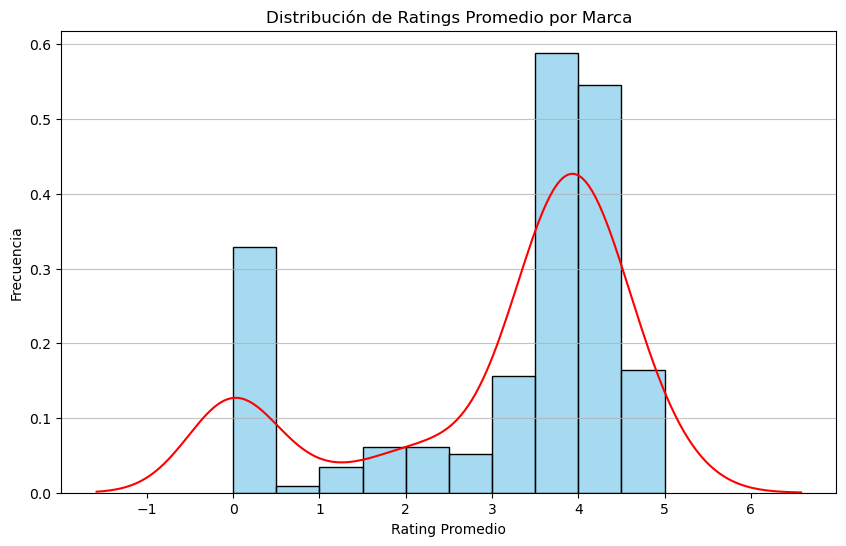

In [16]:

brand_avg_ratings = df.groupby('brand_name')['rating'].mean()


plt.figure(figsize=(10,6))
sns.histplot(brand_avg_ratings, bins=10, color='skyblue', stat='density')
sns.kdeplot(brand_avg_ratings, color='red')
plt.title('Distribución de Ratings Promedio por Marca')
plt.xlabel('Rating Promedio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

Marvin

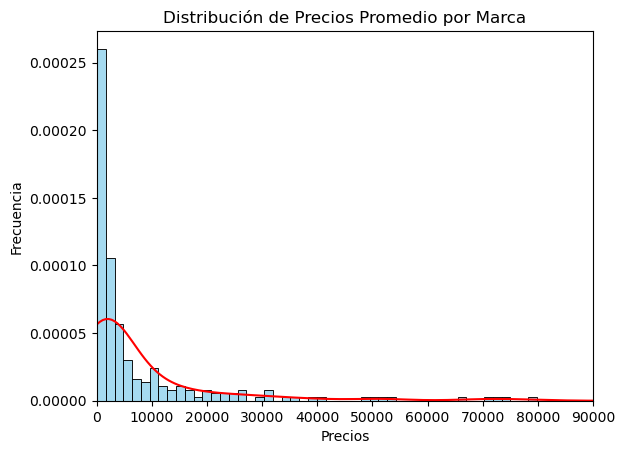

In [17]:
brand_avg_prices = df.groupby('brand_name')['price'].mean()


sns.histplot(brand_avg_prices, bins=50, color='skyblue', stat='density')
sns.kdeplot(brand_avg_prices, color = 'red')
plt.title('Distribución de Precios Promedio por Marca')
plt.xlabel('Precios')
plt.ylabel('Frecuencia')
plt.xlim(0, 90000)
plt.show()

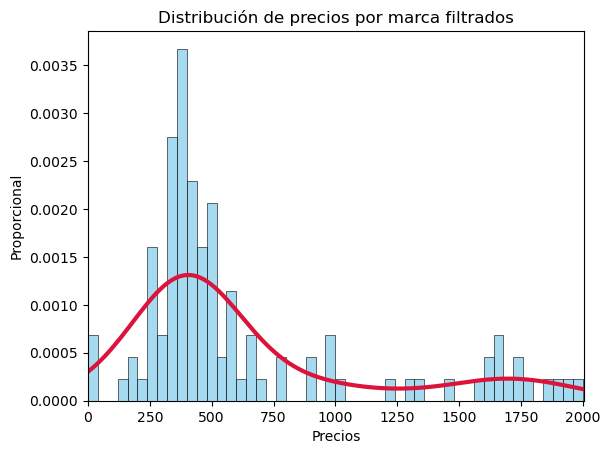

In [18]:
# Ver como es el grafico con filtrando precios
precios_bajos = brand_avg_prices[brand_avg_prices.between(0, 2000)]

sns.kdeplot(precios_bajos, color='crimson', linewidth=3)
sns.histplot(precios_bajos, bins=50, color='skyblue', stat='density')

plt.title('Distribución de precios por marca filtrados')
plt.xlabel('Precios')
plt.ylabel('Proporcional')
plt.xlim(0, 2005)

plt.show()

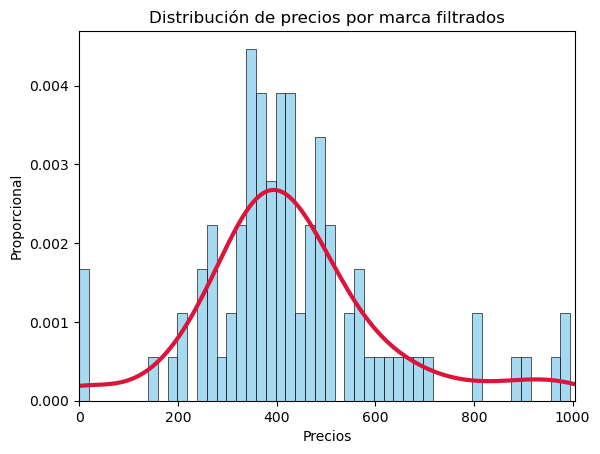

In [19]:
# Ver como es el grafico con filtrando precios
precios_bajos = brand_avg_prices[brand_avg_prices.between(0, 1000)]

sns.kdeplot(precios_bajos, color='crimson', linewidth=3)
sns.histplot(precios_bajos, bins=50, color='skyblue', stat='density')

plt.title('Distribución de precios por marca filtrados')
plt.xlabel('Precios')
plt.ylabel('Proporcional')
plt.xlim(0, 1005)

plt.show()

# Evaluación Parcial 2 — Modelos de Machine Learning
## Dataset: Amazon Men's Wrist Watches

Este notebook implementa el ciclo completo de Machine Learning aplicado a un
dataset de relojes masculinos de Amazon, continuando desde la limpieza realizada
en la Evaluación 1.

### Estructura del trabajo

| Sección | Tipo | Algoritmos |
|---|---|---|
| Feature Engineering | Preparación | Log-transform, escalado |
| Clasificación | Supervisado | Árbol de Decisión, Random Forest + GridSearchCV |
| Regresión | Supervisado | Regresión Lineal, Ridge |
| Clustering | No supervisado | K-Means + PCA |

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline

# Clasificación
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay, f1_score)

# Regresión
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [21]:
df.head(5)



,Unnamed: 0,brand_name,watch_name,rating,number_of_reviews,price,rating_categoria
0,0,Casio,Vintage A-158WA-1Q Digital Grey Dial Unisex Wa...,4.4,54000,1894,Bueno
1,1,Casio,Youth Series Digital Black Dial Unisex Watch -...,4.5,13200,1191,Excelente
2,2,Titan,Karishma Analog Black Dial Men's Watch -NM1639...,4.3,2900,1695,Bueno
3,3,Daniel Hechter,Paris Bercy Collection Modern Multi Functional...,4.3,890,2593,Bueno
4,4,Casio,Unisex-Adult Vintage B650WC-5ADF Rose Gold Dig...,4.5,1100,4494,Excelente


## 1. Feature Engineering

Antes de entrenar cualquier modelo, construimos variables nuevas que mejoren
la capacidad predictiva. Aplicamos transformación logarítmica para corregir
la asimetría (*skewness*) de las distribuciones de precio y reseñas.

### Transformación logarítmica

Para variables con distribución sesgada a la derecha se aplica:

$$x' = \log(1 + x)$$

El $+1$ evita $\log(0)$ cuando la variable puede valer cero.

### Estandarización (StandardScaler)

Para que todas las variables queden en la misma escala:

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar de la variable.

### Features construidas

| Feature | Fórmula | Justificación |
|---|---|---|
| `log_price` | $\log(1+\text{price})$ | Corrige skewness del precio |
| `log_reviews` | $\log(1+\text{reviews})$ | Corrige skewness de reseñas |
| `price_per_review` | $\text{price} / (\text{reviews}+1)$ | Relación valor/popularidad |
| `brand_avg_rating` | Promedio de rating por marca | Reputación de marca |
| `brand_avg_price` | Promedio de precio por marca | Segmento de la marca |

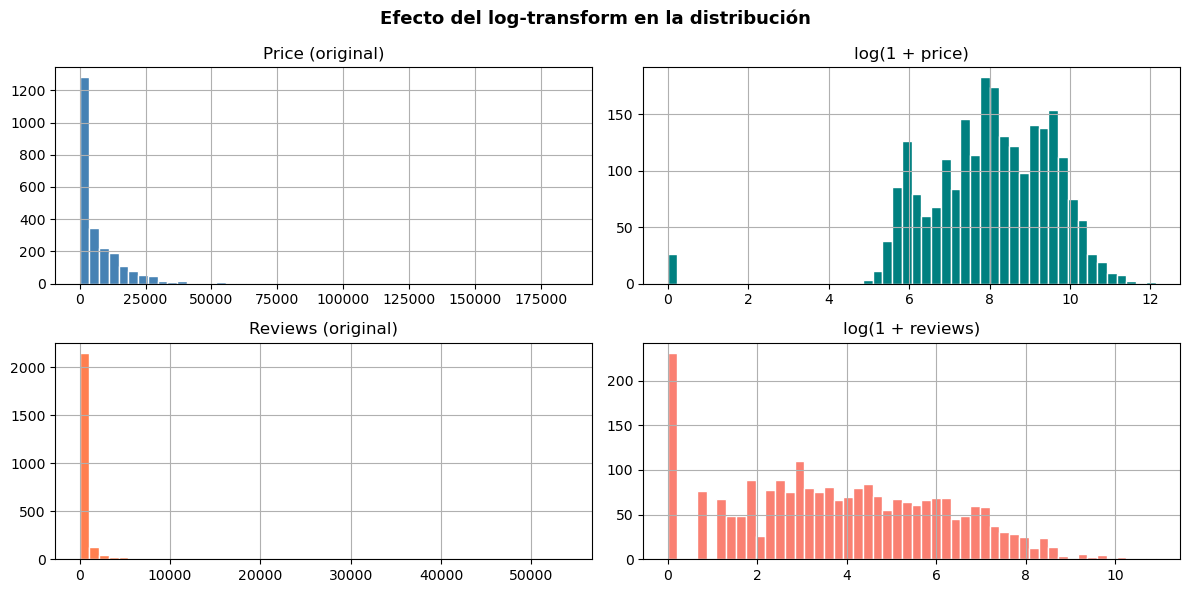

Features construidas: ['log_price', 'log_reviews', 'price_per_review', 'brand_avg_rating', 'brand_avg_price']


In [22]:
# Log-transforms
df['log_price']   = np.log1p(df['price'])
df['log_reviews'] = np.log1p(df['number_of_reviews'])

# Relación precio / popularidad
df['price_per_review'] = df['price'] / (df['number_of_reviews'] + 1)

# Features por marca (reputación y segmento)
brand_stats = df.groupby('brand_name').agg(
    brand_avg_rating=('rating',  'mean'),
    brand_avg_price =('price',   'mean')
).reset_index()
df = df.merge(brand_stats, on='brand_name', how='left')

# Verificar distribuciones antes y después del log
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
df['price'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Price (original)')
df['log_price'].hist(bins=50, ax=axes[0,1], color='teal', edgecolor='white')
axes[0,1].set_title('log(1 + price)')
df['number_of_reviews'].hist(bins=50, ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Reviews (original)')
df['log_reviews'].hist(bins=50, ax=axes[1,1], color='salmon', edgecolor='white')
axes[1,1].set_title('log(1 + reviews)')
plt.suptitle('Efecto del log-transform en la distribución', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Features construidas:", ['log_price','log_reviews','price_per_review',
                                   'brand_avg_rating','brand_avg_price'])

---
Marvin

## 2. Modelo Supervisado — Clasificación

**Problema:** predecir la categoría de rating de un reloj (`Excelente`, `Bueno`, `Bajo`)
a partir de sus características de precio y popularidad.

### Algoritmo 1: Árbol de Decisión

El árbol divide el espacio de features usando el criterio **Gini Impurity**:

$$G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

donde $p_i$ es la proporción de ejemplos de la clase $i$ en el nodo.
Un nodo es "puro" cuando $G(p) = 0$ (solo una clase). El árbol elige
el split que maximiza la reducción de impureza:

$$\Delta G = G(\text{padre}) - \frac{|S_{\text{izq}}|}{|S|}G(\text{izq}) - \frac{|S_{\text{der}}|}{|S|}G(\text{der})$$

### Algoritmo 2: Random Forest

Ensemble de $B$ árboles entrenados sobre muestras bootstrap.
La predicción final es por votación:

$$\hat{y} = \text{moda}\left(\hat{y}^{(1)}, \hat{y}^{(2)}, \ldots, \hat{y}^{(B)}\right)$$

La varianza del ensemble se reduce respecto a un árbol individual:

$$\text{Var}\left(\bar{T}\right) = \rho \cdot \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

donde $\rho$ es la correlación entre árboles (baja gracias al muestreo aleatorio de features).

### Métricas de evaluación

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN}$$

Clases: ['Bajo' 'Bueno' 'Excelente']
Distribución:
rating_categoria
Bueno        1574
Excelente     459
Bajo          367
Name: count, dtype: int64


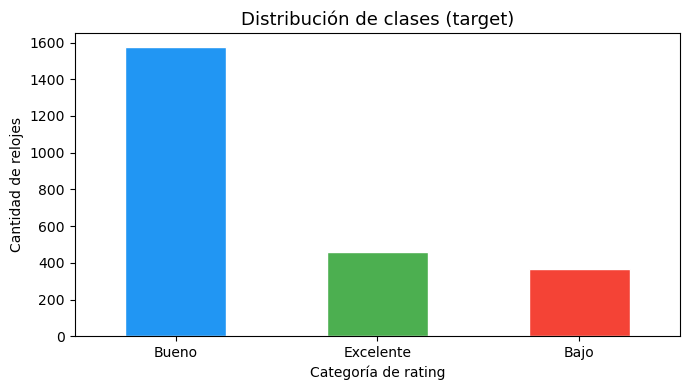

In [23]:
# Features y target
FEATURES_CLF = ['log_price', 'log_reviews']

X_clf = df[FEATURES_CLF].copy()
y_clf = df['rating_categoria']

# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y_clf)
clases = le.classes_

print("Clases:", clases)
print("Distribución:")
print(y_clf.value_counts())

# Verificar balance de clases
fig, ax = plt.subplots(figsize=(7, 4))
y_clf.value_counts().plot(kind='bar', color=['#2196F3','#4CAF50','#F44336'],
                          edgecolor='white')
ax.set_title('Distribución de clases (target)', fontsize=13)
ax.set_xlabel('Categoría de rating')
ax.set_ylabel('Cantidad de relojes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

=== Árbol de Decisión (baseline) ===
Accuracy : 0.7792
F1-score : 0.7719

              precision    recall  f1-score   support

        Bajo       1.00      0.64      0.78        73
       Bueno       0.82      0.91      0.86       315
   Excelente       0.49      0.42      0.45        92

    accuracy                           0.78       480
   macro avg       0.77      0.66      0.70       480
weighted avg       0.78      0.78      0.77       480



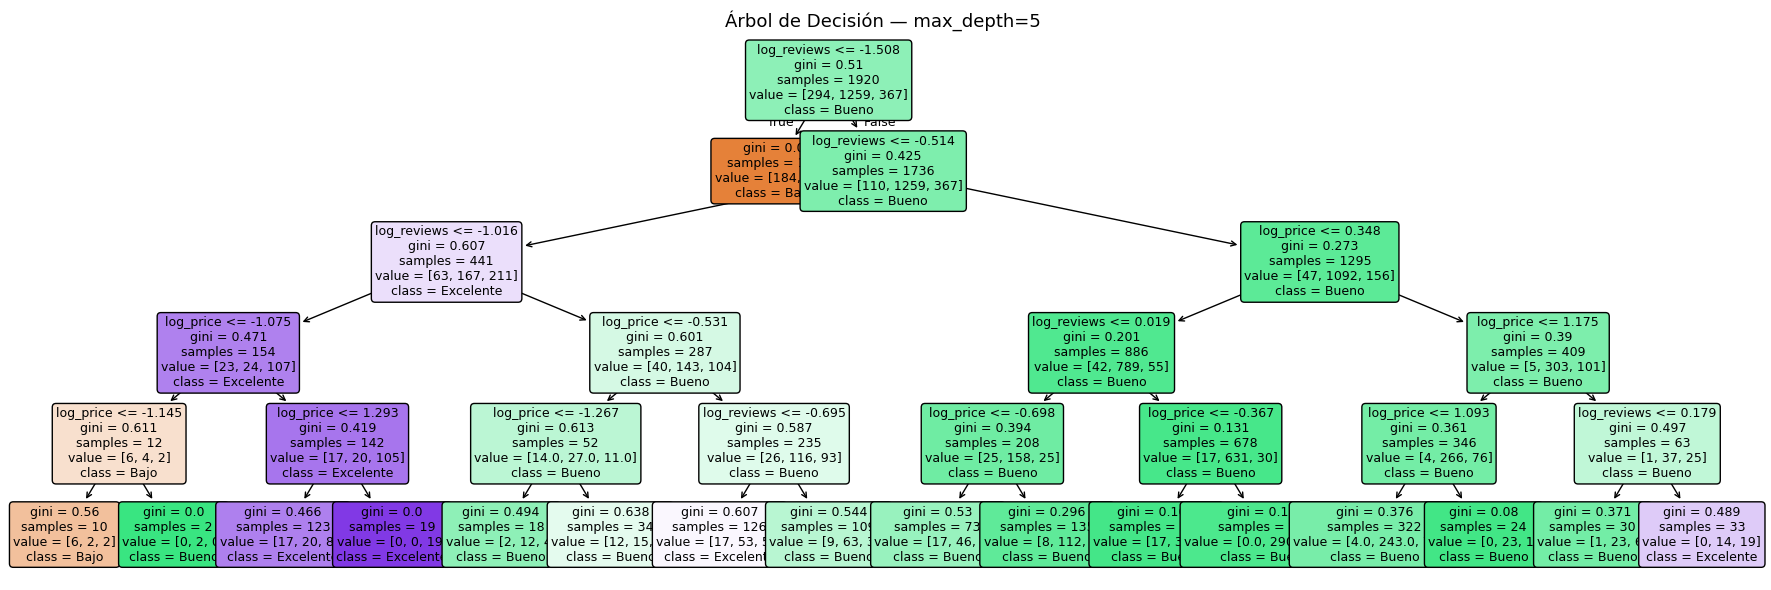

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar
scaler_clf = StandardScaler()
X_train_s = scaler_clf.fit_transform(X_train)
X_test_s  = scaler_clf.transform(X_test)

# Árbol baseline
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_s, y_train)
y_pred_dt = dt.predict(X_test_s)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')

print(f"=== Árbol de Decisión (baseline) ===")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=clases))

# Visualizar árbol
plt.figure(figsize=(18, 6))
plot_tree(dt, feature_names=FEATURES_CLF, class_names=clases,
          filled=True, rounded=True, fontsize=9)
plt.title('Árbol de Decisión — max_depth=5', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Definir grilla de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [5, 10],
    'min_samples_split': [2],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train_s, y_train)

best_rf   = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_s)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print(f"=== Random Forest (optimizado con GridSearchCV) ===")
print(f"Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"Accuracy : {acc_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=clases))

=== Random Forest (optimizado con GridSearchCV) ===
Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Accuracy : 0.7937
F1-score : 0.7751

              precision    recall  f1-score   support

        Bajo       1.00      0.64      0.78        73
       Bueno       0.80      0.96      0.87       315
   Excelente       0.56      0.35      0.43        92

    accuracy                           0.79       480
   macro avg       0.79      0.65      0.70       480
weighted avg       0.79      0.79      0.78       480



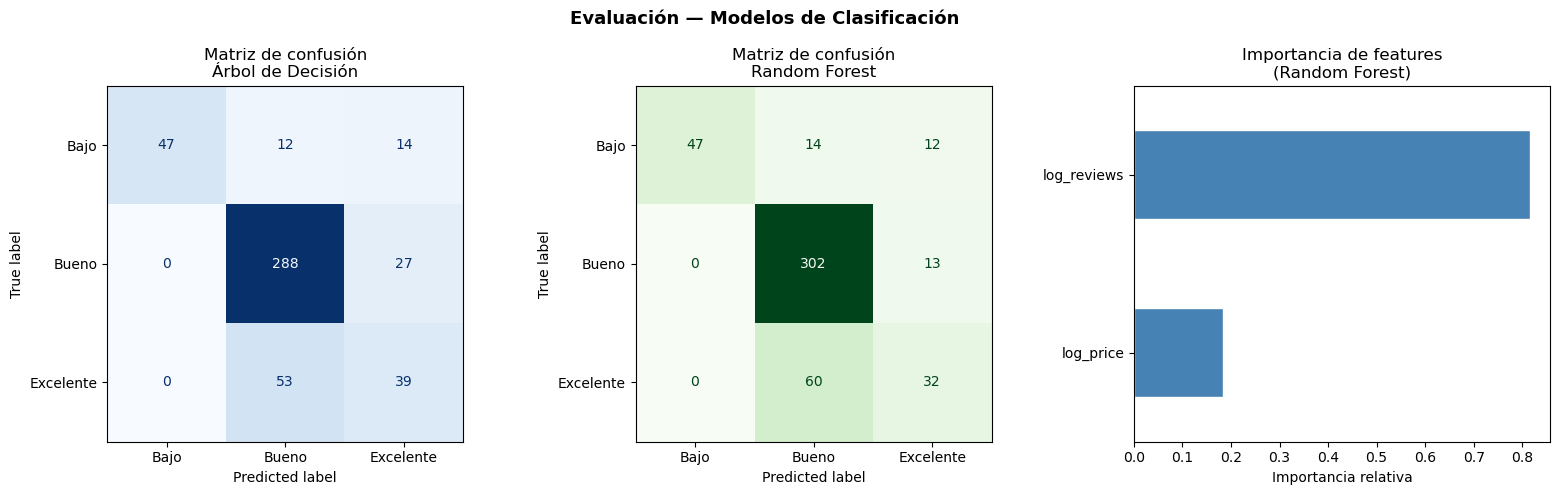


=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===


,Modelo,Accuracy,F1-score
0,Árbol de Decisión,0.7792,0.7719
1,Random Forest (GridSearchCV),0.7937,0.7751


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriz de confusión - Árbol
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=clases).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusión\nÁrbol de Decisión')

# Matriz de confusión - Random Forest
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=clases).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de confusión\nRandom Forest')
# Importancia de features

# The original error indicates that best_rf.feature_importances_ has 5 values,
# but FEATURES_CLF has only 2. Assuming best_rf was intended to be trained on the
# 5 features defined in FEATURES_CLU, we use FEATURES_CLU as the index.
importancias = pd.Series(best_rf.feature_importances_, index=FEATURES_CLF).sort_values()
importancias.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Importancia de features\n(Random Forest)')
axes[2].set_xlabel('Importancia relativa')

plt.suptitle('Evaluación — Modelos de Clasificación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla comparativa
print("\n=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===")
resultados_clf = pd.DataFrame({
    'Modelo':   ['Árbol de Decisión', 'Random Forest (GridSearchCV)'],
    'Accuracy': [round(acc_dt, 4),   round(acc_rf, 4)],
    'F1-score': [round(f1_dt, 4),    round(f1_rf, 4)]
})
display(resultados_clf)

---
Ricardo


## 3. Modelo Supervisado — Regresión

**Problema:** predecir el precio de un reloj (variable continua) a partir de sus
características.

### Regresión Lineal

El modelo busca los coeficientes $\boldsymbol{\beta}$ que minimizan el error cuadrático:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

La solución cerrada (mínimos cuadrados ordinarios) es:

$$\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T \mathbf{y}$$

### Regresión Ridge (regularización L2)

Agrega una penalización sobre los coeficientes para evitar sobreajuste:

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2 \right\}$$

donde $\lambda \geq 0$ controla la fuerza de la regularización.

### Métricas de evaluación

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

$R^2 = 1$ indica predicción perfecta; $R^2 = 0$ equivale a predecir siempre la media.

In [27]:
FEATURES_REG = ['rating', 'log_reviews', 'price_per_review',
                'brand_avg_rating', 'brand_avg_price']

X_reg = df[FEATURES_REG].copy()
y_reg = df['log_price']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_tr_s = scaler_reg.fit_transform(X_tr)
X_te_s  = scaler_reg.transform(X_te)

# Regresión Lineal
lr = LinearRegression()
lr.fit(X_tr_s, y_tr)
y_pred_lr = lr.predict(X_te_s)

rmse_lr = np.sqrt(mean_squared_error(y_te, y_pred_lr))
mae_lr  = mean_absolute_error(y_te, y_pred_lr)
r2_lr   = r2_score(y_te, y_pred_lr)

# Ridge
alphas = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), alphas, cv=5, scoring='r2')
ridge_cv.fit(X_tr_s, y_tr)
best_ridge   = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_te_s)

rmse_ridge = np.sqrt(mean_squared_error(y_te, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_te, y_pred_ridge)
r2_ridge   = r2_score(y_te, y_pred_ridge)

print(f"=== Regresión Lineal ===")
print(f"RMSE: {rmse_lr:.4f} | MAE: {mae_lr:.4f} | R²: {r2_lr:.4f}")
print(f"\n=== Ridge (alpha={ridge_cv.best_params_['alpha']}) ===")
print(f"RMSE: {rmse_ridge:.4f} | MAE: {mae_ridge:.4f} | R²: {r2_ridge:.4f}")

# Tabla comparativa
resultados_reg = pd.DataFrame({
    'Modelo':  ['Regresión Lineal', 'Ridge'],
    'RMSE':    [round(rmse_lr,4),   round(rmse_ridge,4)],
    'MAE':     [round(mae_lr,4),    round(mae_ridge,4)],
    'R²':      [round(r2_lr,4),     round(r2_ridge,4)]
})
display(resultados_reg)

=== Regresión Lineal ===
RMSE: 1.1765 | MAE: 0.7975 | R²: 0.4050

=== Ridge (alpha=10) ===
RMSE: 1.1759 | MAE: 0.7981 | R²: 0.4056


,Modelo,RMSE,MAE,R²
0,Regresión Lineal,1.1765,0.7975,0.4050
1,Ridge,1.1759,0.7981,0.4056


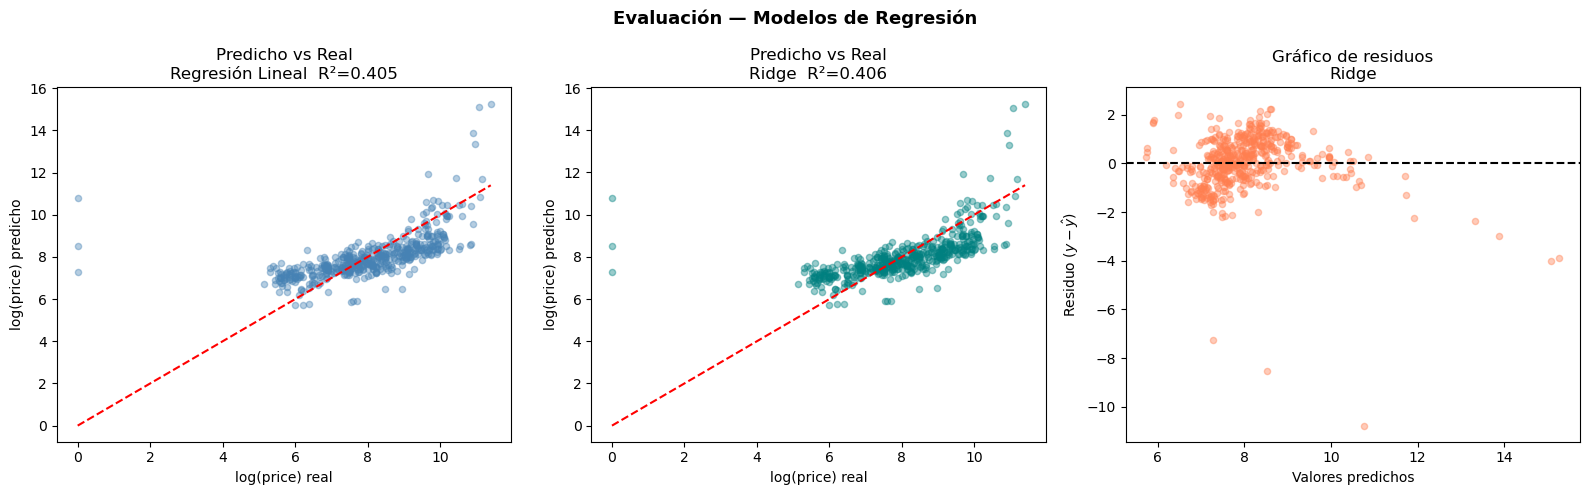

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicho vs Real - Lineal
axes[0].scatter(y_te, y_pred_lr, alpha=0.4, color='steelblue', s=20)
lims = [y_te.min(), y_te.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_title(f'Predicho vs Real\nRegresión Lineal  R²={r2_lr:.3f}')
axes[0].set_xlabel('log(price) real')
axes[0].set_ylabel('log(price) predicho')

# Predicho vs Real - Ridge
axes[1].scatter(y_te, y_pred_ridge, alpha=0.4, color='teal', s=20)
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_title(f'Predicho vs Real\nRidge  R²={r2_ridge:.3f}')
axes[1].set_xlabel('log(price) real')
axes[1].set_ylabel('log(price) predicho')

# Residuos Ridge
residuos = y_te - y_pred_ridge
axes[2].scatter(y_pred_ridge, residuos, alpha=0.4, color='coral', s=20)
axes[2].axhline(0, color='black', lw=1.5, linestyle='--')
axes[2].set_title('Gráfico de residuos\nRidge')
axes[2].set_xlabel('Valores predichos')
axes[2].set_ylabel('Residuo ($y - \hat{y}$)')

plt.suptitle('Evaluación — Modelos de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
Marvin

## 4. Modelo No Supervisado — Clustering + PCA

**Problema:** descubrir segmentos naturales de relojes sin usar etiquetas,
agrupando por precio, rating y popularidad.

### Algoritmo: K-Means

K-Means minimiza la **inercia** (suma de distancias cuadradas intra-cluster):

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

donde $\mu_k$ es el centroide del cluster $k$.

### Selección del K óptimo

**Método del codo:** buscamos el punto donde la reducción de inercia se aplana.

**Silhouette Score:** mide qué tan bien separado está cada punto respecto a su
cluster comparado con el cluster más cercano:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

donde $a(i)$ = distancia media intra-cluster y $b(i)$ = distancia media al cluster
vecino más cercano. El rango es $[-1, 1]$: valores cercanos a $1$ indican
buena separación.

### PCA para visualización

PCA encuentra las direcciones de máxima varianza. La varianza explicada por
cada componente $k$ es:

$$\text{VE}_k = \frac{\lambda_k}{\displaystyle\sum_{j=1}^{p}\lambda_j} \times 100\%$$

donde $\lambda_k$ es el $k$-ésimo valor propio de la matriz de covarianza.

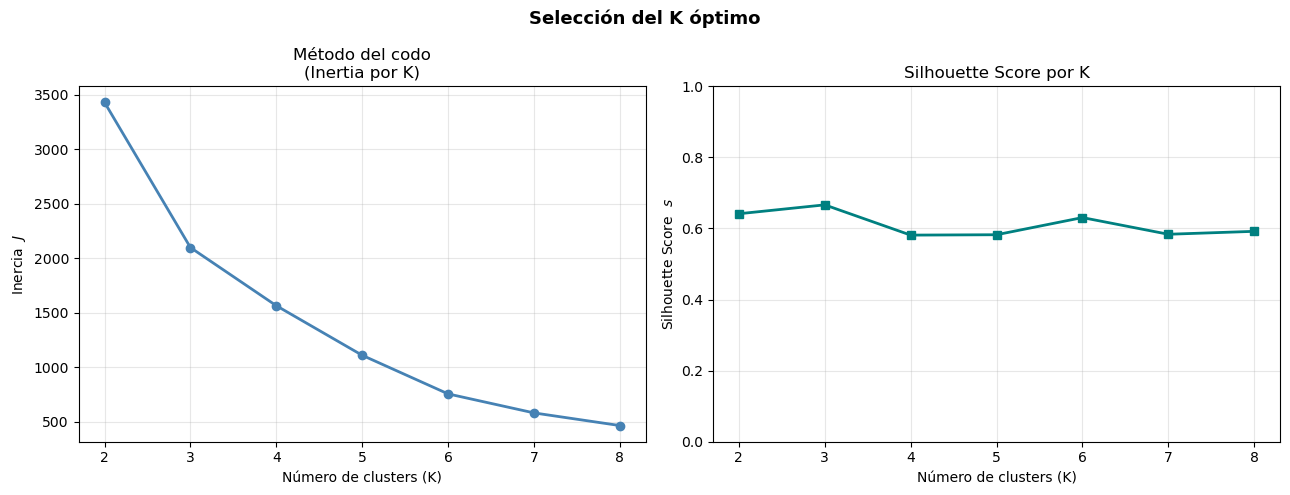

,K,Inertia,Silhouette
0,2,3430.8,0.6413
1,3,2098.4,0.6663
2,4,1564.4,0.5812
3,5,1109.2,0.5822
4,6,754.9,0.6305
5,7,580.5,0.5836
6,8,464.3,0.5918


In [29]:
FEATURES_CLU = ['price', 'number_of_reviews']

X_clu = df[FEATURES_CLU].copy()
scaler_clu = StandardScaler()
X_clu_s = scaler_clu.fit_transform(X_clu)

inertias    = []
silhouettes = []
k_range     = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clu_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clu_s, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Codo
axes[0].plot(k_range, inertias, marker='o', color='steelblue', lw=2)
axes[0].set_title('Método del codo\n(Inertia por K)', fontsize=12)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia  $J$')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_range, silhouettes, marker='s', color='teal', lw=2)
axes[1].set_title('Silhouette Score por K', fontsize=12)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score  $s$')
axes[1].set_xticks(list(k_range))
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.suptitle('Selección del K óptimo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de resultados
tabla_k = pd.DataFrame({'K': list(k_range),
                         'Inertia': [round(i,1) for i in inertias],
                         'Silhouette': [round(s,4) for s in silhouettes]})
display(tabla_k)

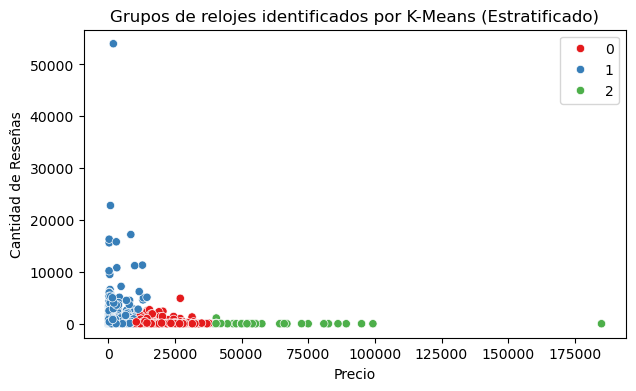

In [30]:
X = df[['price', 'number_of_reviews']]
y = df['rating_categoria']

sil_final = silhouettes[1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K_OPTIMO = 3
# Clusters basados en la respuesta Inercia-Silhoutte, además de una visualización
modelo_kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42)

# Agrupamos usando los datos de entrenamiento escalados
grupos_entrenamiento = modelo_kmeans.fit_predict(X_train_scaled)

# Gráfico para el informe: Muestra cómo se agruparon los relojes
plt.figure(figsize=(7, 4))
sns.scatterplot(data=X_train, x='price', y='number_of_reviews', hue=grupos_entrenamiento, palette='Set1')
plt.title('Grupos de relojes identificados por K-Means (Estratificado)')
plt.xlabel('Precio')
plt.ylabel('Cantidad de Reseñas')
plt.show()

---
Ricardo

PC1 explica: 54.5%
PC2 explica: 45.5%
Total explicado: 100.0%


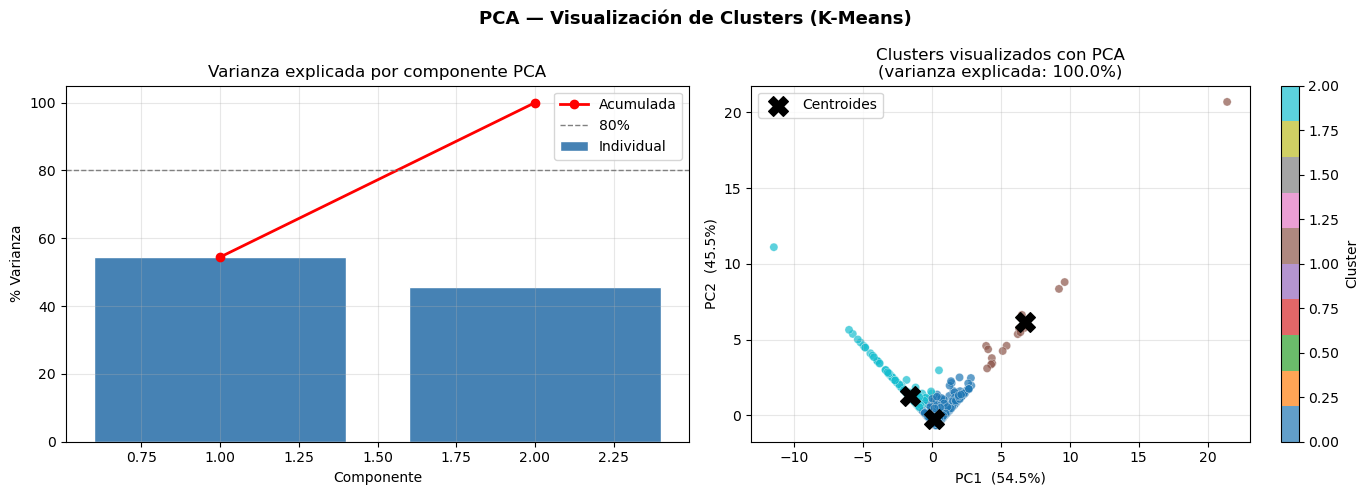

In [31]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_clu_s)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clu_s)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
total_var = var1 + var2

print(f"PC1 explica: {var1:.1f}%")
print(f"PC2 explica: {var2:.1f}%")
print(f"Total explicado: {total_var:.1f}%")

# Varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA acumulada
pca_full = PCA(random_state=42).fit(X_clu_s)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[0].bar(range(1, len(var_acum)+1), pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='white', label='Individual')
axes[0].plot(range(1, len(var_acum)+1), var_acum, marker='o', color='red',
             lw=2, label='Acumulada')
axes[0].axhline(80, color='gray', linestyle='--', lw=1, label='80%')
axes[0].set_title('Varianza explicada por componente PCA')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('% Varianza')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter PCA coloreado por cluster
colores  = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']
paleta   = [colores[c] for c in df['cluster']]
scatter  = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=df['cluster'], cmap='tab10',
                           alpha=0.7, s=35, edgecolors='white', linewidths=0.3)

# Centroides en espacio PCA
centroides_pca = pca.transform(km_final.cluster_centers_)
axes[1].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                marker='X', s=200, color='black', zorder=5, label='Centroides')

axes[1].set_title(f'Clusters visualizados con PCA\n(varianza explicada: {total_var:.1f}%)')
axes[1].set_xlabel(f'PC1  ({var1:.1f}%)')
axes[1].set_ylabel(f'PC2  ({var2:.1f}%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.suptitle('PCA — Visualización de Clusters (K-Means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

['Unnamed: 0', 'brand_name', 'watch_name', 'rating', 'number_of_reviews', 'price', 'rating_categoria', 'log_price', 'log_reviews', 'price_per_review', 'brand_avg_rating', 'brand_avg_price', 'cluster']


,price,rating,number_of_reviews,price_per_review,brand_avg_price,n_relojes
cluster,,,,,,
0,4420.73,3.78,396.40,701.41,5367.17,2096
1,2848.50,4.11,16862.50,0.22,6128.21,16
2,30114.93,3.47,117.93,10687.99,23044.70,288


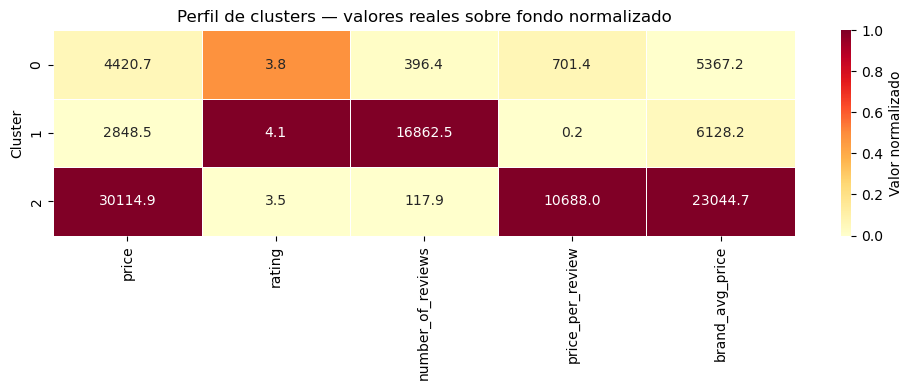


Interpretación de negocio 

Relojes accesibles  (n=2096)
  Precio promedio:  $4,421
  Rating promedio:  3.78
  Reseñas prom.:    396

Rango medio  (n=16)
  Precio promedio:  $2,848
  Rating promedio:  4.11
  Reseñas prom.:    16,862

Premium / alta gama  (n=288)
  Precio promedio:  $30,115
  Rating promedio:  3.47
  Reseñas prom.:    118


In [32]:
vars_analisis = ['price', 'rating', 'number_of_reviews','price_per_review', 'brand_avg_price']
print(df.columns.tolist())
resumen = df.groupby('cluster')[vars_analisis].mean().round(2)
resumen['n_relojes'] = df.groupby('cluster').size()
display(resumen)

# Perfil visual de clusters
resumen_norm = (resumen[vars_analisis] - resumen[vars_analisis].min()) / \
               (resumen[vars_analisis].max() - resumen[vars_analisis].min())

plt.figure(figsize=(10, 4))
sns.heatmap(resumen_norm, annot=resumen[vars_analisis], fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Valor normalizado'})
plt.title('Perfil de clusters — valores reales sobre fondo normalizado', fontsize=12)
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Nombres descriptivos de negocio
nombres = {0: 'Relojes accesibles', 1: 'Rango medio', 2: 'Premium / alta gama'}
print("\nInterpretación de negocio ")
for k, nombre in nombres.items():
    fila = resumen.loc[k]
    print(f"\n{nombre}  (n={int(fila['n_relojes'])})")
    print(f"  Precio promedio:  ${fila['price']:,.0f}")
    print(f"  Rating promedio:  {fila['rating']:.2f}")
    print(f"  Reseñas prom.:    {fila['number_of_reviews']:,.0f}")

## 5. Comparación global de modelos

In [33]:
resultados_clf = pd.DataFrame({
    'Modelo':   ['Árbol de Decisión', 'Random Forest (GridSearchCV)'],
    'Accuracy': [round(acc_dt, 4),   round(acc_rf, 4)],
    'F1-score (weighted)': [round(f1_dt, 4),    round(f1_rf, 4)]
})

resultados_reg = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Ridge'],
    'RMSE': [rmse_lr, rmse_ridge],
    'MAE': [mae_lr, mae_ridge],
    'R²': [r2_lr, r2_ridge]
})

print("--- DESEMPEÑO DE CLASIFICACIÓN (Categorización) ---")
display(resultados_clf)
print("\n--- DESEMPEÑO DE REGRESIÓN (Predicción de Precio) ---")
display(resultados_reg)

--- DESEMPEÑO DE CLASIFICACIÓN (Categorización) ---


,Modelo,Accuracy,F1-score (weighted)
0,Árbol de Decisión,0.7792,0.7719
1,Random Forest (GridSearchCV),0.7937,0.7751



--- DESEMPEÑO DE REGRESIÓN (Predicción de Precio) ---


,Modelo,RMSE,MAE,R²
0,Regresión Lineal,1.176533,0.797487,0.405037
1,Ridge,1.175932,0.798089,0.405645


## 6. Visualizaciones Interactivas con Plotly

Aquí presentamos una serie de visualizaciones interactivas utilizando Plotly, que permiten una exploración más dinámica de los datos.

In [34]:
import plotly.express as px
import plotly.graph_objects as go
# brand_avg_ratings = df.groupby('brand_name')['rating'].mean()

fig = px.histogram(brand_avg_ratings, x=brand_avg_ratings.name,
                   title='Distribución Interactiva de Ratings Promedio por Marca',
                   labels={'value': 'Rating Promedio', 'count': 'Número de Marcas'})
fig.update_layout(xaxis_title='Rating Promedio', yaxis_title='Número de Marcas')
fig.show()

ModuleNotFoundError: No module named 'plotly'

### Interpretación: Distribución Interactiva de Ratings Promedio por Marca

Este histograma interactivo muestra cómo se distribuyen los ratings promedio de las diferentes marcas. Podemos observar lo siguiente:

*   **Concentración en ratings altos:** La mayoría de las marcas tienen un rating promedio cercano a 4.0 o superior, lo que sugiere que la calidad general percibida de los relojes en el dataset es buena.
*   **Bimodalidad:** Hay un pico notable alrededor de 4.0-4.5 y otro más pequeño alrededor de 0, lo que indica que existen marcas con ratings muy bajos (posiblemente por falta de reseñas o baja calidad) y una gran cantidad de marcas con ratings consistentemente buenos.
*   **Interactividad:** Al pasar el cursor sobre las barras, se puede ver el rango exacto de ratings y la cantidad de marcas que caen en ese rango, lo que facilita la identificación de los segmentos de marcas según su reputación.

In [ ]:
# brand_avg_prices = df.groupby('brand_name')['price'].mean()

fig = px.histogram(brand_avg_prices, x=brand_avg_prices.name,
                   title='Distribución Interactiva de Precios Promedio por Marca',
                   labels={'value': 'Precio Promedio', 'count': 'Número de Marcas'},
                   nbins=50)
fig.update_xaxes(range=[0, 90000]) # Mantener el límite similar al gráfico original
fig.update_layout(xaxis_title='Precio Promedio', yaxis_title='Número de Marcas')
fig.show()

### Interpretación: Distribución Interactiva de Precios Promedio por Marca

Este histograma interactivo muestra la distribución de los precios promedio de los relojes por marca. Se puede extraer la siguiente información:

*   **Marcas de bajo precio:** Hay una concentración muy alta de marcas con precios promedio bajos (por debajo de $5,000), lo que indica un mercado muy competitivo en ese segmento.
*   **Cola larga:** Existe una "cola larga" hacia la derecha, lo que significa que, aunque menos comunes, hay algunas marcas con precios promedio muy elevados, representando el segmento de lujo o alta gama.
*   **Interactividad:** La interactividad permite explorar los rangos de precios específicos y la cantidad de marcas en cada uno, facilitando la detección de nichos de mercado o la identificación de marcas premium.

In [37]:
import plotly.express as px
import plotly.graph_objects as go

# Re-calcular var1 y var2 para asegurar que estén disponibles en esta celda

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# Crear un DataFrame para Plotly con los componentes PCA, los clusters y las features originales
df_pca_plotly = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca_plotly['Cluster'] = df['cluster'].map({0: 'Relojes accesibles', 1: 'Rango medio', 2: 'Premium / alta gama'})
# Añadir las características originales para el hover
df_pca_plotly['Price'] = df['price']
df_pca_plotly['Number of Reviews'] = df['number_of_reviews']

# Crear el gráfico de dispersión con una paleta de colores más distintiva
fig = px.scatter(df_pca_plotly, x='PC1', y='PC2', color='Cluster',
                 title='Clusters de Relojes con PCA (Plotly Interactivo)',
                 labels={'PC1': f'PC1 ({var1:.1f}%)', 'PC2': f'PC2 ({var2:.1f}%)'},
                 hover_data={'PC1': ':.2f', 'PC2': ':.2f', 'Cluster': True, 'Price': True, 'Number of Reviews': True},
                 color_discrete_sequence=px.colors.qualitative.Bold) # Uso de una paleta más contrastante

fig.update_traces(marker=dict(size=12, opacity=1.0, line=dict(width=1.0, color='Black'))) # Revertir a tamaño original y grosor de borde
fig.update_layout(legend_title_text='Segmento de Cliente')

# Añadir los centroides de los clusters con su tamaño original
centroides_pca = pca.transform(km_final.cluster_centers_)
fig.add_trace(go.Scatter(
    x=centroides_pca[:, 0],
    y=centroides_pca[:, 1],
    mode='markers',
    marker=dict(symbol='x', size=15, color='black', line=dict(width=2)), # Revertir a tamaño y grosor de línea original del centroide
    name='Centroides',
    hoverinfo='name'
))

fig.show()

### Interpretación: Clusters de Relojes con PCA (Interactiva)

Esta visualización interactiva de los clusters mediante las dos primeras componentes principales (PC1 y PC2) ofrece una perspectiva clara de cómo se agrupan los relojes:

*   **Separación de clusters:** Se observa que los tres segmentos de relojes ("Relojes accesibles", "Rango medio", "Premium / alta gama") están razonablemente bien separados en este espacio bidimensional, lo que valida la utilidad del clustering K-Means.
*   **Contribución de las componentes:** PC1 (54.5%) y PC2 (45.5%) explican el 100% de la varianza en las características utilizadas para el clustering (`price` y `number_of_reviews`). Esto significa que estas dos componentes capturan toda la información relevante para distinguir los grupos.
*   **Identificación de grupos:**
    *   El grupo "Relojes accesibles" se ubica en un área distinta, caracterizado por precios y reseñas más bajos.
    *   El grupo "Rango medio" se distingue por un número muy alto de reseñas, aunque con precios bajos.
    *   El grupo "Premium / alta gama" se diferencia por los precios más altos y un número de reseñas relativamente bajo.
*   **Interactividad:** Al pasar el cursor sobre cada punto, se puede identificar el cluster al que pertenece y los valores de PC1 y PC2, lo que facilita la comprensión de la posición de cada reloj en el espacio de características transformado.